# Bag of Words Exploration Notebook

## 1. Setup 

In [13]:
import os
import glob
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

# Directory containing .txt files
TEXT_DIR = "text" 

# Directory containing other metadata
DATA_DIR = "data"

## 2. Load documents 

In [2]:
filepaths = glob.glob(os.path.join(TEXT_DIR, "*.txt"))

corpus = []
filenames = []

for fp in filepaths:
    with open(fp, 'r', encoding='utf-8', errors='ignore') as f:
        corpus.append(f.read())
        filenames.append(os.path.basename(fp))

print(f"Loaded {len(corpus)} documents")

Loaded 762 documents


## 3. Create Bag-of-Words representation 

In [3]:
# https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html

vectorizer = CountVectorizer(
    strip_accents='unicode',
    stop_words='english',
    max_df=0.80,
    min_df=3
)

X = vectorizer.fit_transform(corpus)

print("Matrix shape:", X.shape)

Matrix shape: (762, 32039)


## 4. Convert to DataFrame for exploration 

In [4]:
feature_names = vectorizer.get_feature_names_out()

bow_df = pd.DataFrame(X.toarray(), columns=feature_names, index=filenames)

bow_df.head()

,00,000,01,02,03,05,07,09,10,100,...,zoning,zoo,zoom,zoomed,zooming,zooms,zoos,zora,zu,zucchini
412 Brisk Money.txt,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
164 Specimen 313.txt,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
270 When We Were Heroes.txt,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
720 Tie A Yellow Ribbon.txt,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
176 Apologue.txt,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 5. Most common words overall 

In [5]:
word_counts = bow_df.sum(axis=0).sort_values(ascending=False)

print("Top 20 words:")
print(word_counts.head(20))

Top 20 words:
looked    5749
says      4596
door      4514
wasn      4131
asked     3967
night     3912
turned    3828
maybe     3638
felt      3448
saw       3367
really    3199
couldn    3168
woman     3119
mother    3048
father    3004
body      2954
water     2934
wanted    2873
dead      2846
house     2832
dtype: int64


## 6. Most important words per document 

In [6]:
def top_words_per_doc(df, n=10):
    results = {}
    for doc in df.index:
        top_words = df.loc[doc].sort_values(ascending=False).head(n)
        results[doc] = top_words[top_words > 0]
    return results

per_doc = top_words_per_doc(bow_df)

# Example: show one document
example_doc = list(per_doc.keys())[0]
print(f"\nTop words in {example_doc}:")
print(per_doc[example_doc])


Top words in 412 Brisk Money.txt:
ada       88
gun       35
door      32
maybe     32
wasn      32
car       30
memory    28
job       26
phone     24
looked    24
Name: 412 Brisk Money.txt, dtype: int64


## 7. Document similarity (cosine similarity) 

In [7]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(X)

sim_df = pd.DataFrame(similarity_matrix, index=filenames, columns=filenames)

sim_df.head()

,412 Brisk Money.txt,164 Specimen 313.txt,270 When We Were Heroes.txt,720 Tie A Yellow Ribbon.txt,176 Apologue.txt,616 Dark Warm Heart.txt,186 Tortured.txt,107 River of Souls.txt,659 Grace's Family.txt,006 The Things That Make Me Weak and Strange Get Engineered Away.txt,...,131 Our Candidate.txt,378 Noma Girl.txt,568 The Night Cyclist.txt,221 At the Foot of the Lighthouse (Todai Moto Kurashi).txt,555 Once More Into the Abyss.txt,589 The Thing About Growing up in Jokertown.txt,"525 Tom, Thom.txt",108 Intersections and Interlopers.txt,825 The Sisters of Saint Nicola of The Almost Perpetual Motion vs the Lurch.txt,629 Waiting on a Bright Moon.txt
412 Brisk Money.txt,1.000000,0.148750,0.297533,0.238817,0.081082,0.221968,0.134388,0.207155,0.194037,0.284404,...,0.165428,0.277338,0.257973,0.156820,0.176503,0.233274,0.084129,0.136607,0.128794,0.167484
164 Specimen 313.txt,0.148750,1.000000,0.165727,0.145089,0.052178,0.130469,0.116257,0.126397,0.141645,0.133057,...,0.121581,0.124779,0.146631,0.124627,0.116315,0.134355,0.056594,0.076299,0.108554,0.114120
270 When We Were Heroes.txt,0.297533,0.165727,1.000000,0.248772,0.096157,0.217128,0.148398,0.223176,0.233984,0.276509,...,0.171956,0.266546,0.275503,0.327468,0.257491,0.442370,0.272271,0.143765,0.147878,0.328927
720 Tie A Yellow Ribbon.txt,0.238817,0.145089,0.248772,1.000000,0.079077,0.181912,0.140225,0.211258,0.202106,0.208812,...,0.311027,0.211701,0.188389,0.164239,0.189526,0.189629,0.101306,0.158254,0.145442,0.152683
176 Apologue.txt,0.081082,0.052178,0.096157,0.079077,1.000000,0.072718,0.064737,0.114175,0.073022,0.098044,...,0.090882,0.073583,0.096742,0.073696,0.053419,0.097665,0.044828,0.063412,0.061996,0.122875


## 8. Find most similar documents 

In [8]:
def most_similar(df, doc_name, top_n=5):
    sims = df.loc[doc_name].drop(doc_name)
    return sims.sort_values(ascending=False).head(top_n)

print(f"\nDocuments most similar to {example_doc}:")
print(most_similar(sim_df, example_doc))


Documents most similar to 412 Brisk Money.txt:
875 The Sound of Reindeer.txt                     0.416282
300 The Button Man and the Murder Tree.txt        0.381915
148 The Rook.txt                                  0.381115
180 Trading Hearts at the Half Kaffe Café.txt    0.377699
794 Black Leg.txt                                 0.373516
Name: 412 Brisk Money.txt, dtype: float64


## 9. Optional: visualize top words 

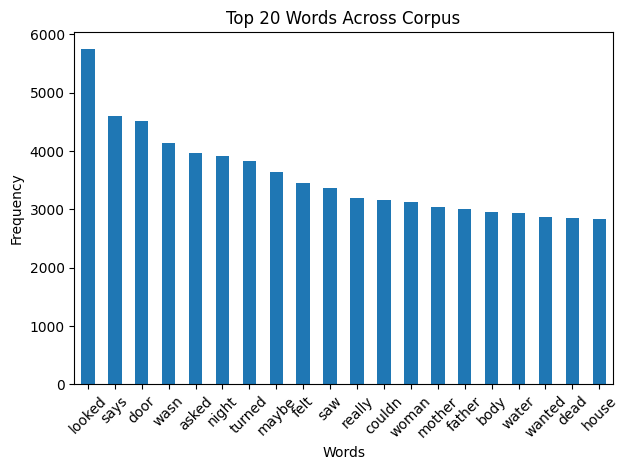

In [9]:
import matplotlib.pyplot as plt

word_counts.head(20).plot(kind='bar')
plt.title("Top 20 Words Across Corpus")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 10. Save outputs 

In [10]:
bow_df.to_csv("outputs/bow_matrix.csv")
sim_df.to_csv("outputs/document_similarity.csv")

print("Saved outputs: bow_matrix.csv, document_similarity.csv")

Saved outputs: bow_matrix.csv, document_similarity.csv


# Sanity Checks

### 1. Locate document pairs with highest similarity.

In [14]:
# Grab just the upper triangle (excluding diagonal).
# This eliminates documents trivial pairs (like documents being similar to themselves)
upper_tri = np.triu(np.ones(sim_df.shape), k=1).astype(bool)

filtered = sim_df.where(upper_tri)

In [17]:
# We'll pull the most similar 5 pairs

top_pairs = (
    filtered.stack()
    .sort_values(ascending=False)
    .head(5)
)
top_pairs

857 The City Born Great.txt                569 The City Born Great.txt                                                                 1.0
371 The Tallest Doll in New York City.txt  648 A Valentine from Maria Dahvana Headley- Read "The Tallest Doll in New York City".txt    1.0
621 Caligo Lane.txt                        588 Caligo Lane.txt                                                                         1.0
122 Sweetheart.txt                         669 Read Abbey Mei Otis' "Sweetheart".txt                                                   1.0
476 House.txt                              286 House.txt                                                                               1.0
dtype: float64

In [22]:
duplicates_99 = []

threshold = 0.99  # adjust (0.9–0.99 depending on strictness)

n = similarity_matrix.shape[0]

for i in range(n):
    for j in range(i+1, n):
        if similarity_matrix[i, j] > threshold:
            duplicates_99.append((filenames[i], filenames[j], similarity_matrix[i, j]))

print("Near-duplicate pairs:")
for d in duplicates_99:
    print(d)

Near-duplicate pairs:
('855 The Devil in America.txt', '381 The Devil in America.txt', np.float64(0.9999860455488326))
('371 The Tallest Doll in New York City.txt', '648 A Valentine from Maria Dahvana Headley- Read "The Tallest Doll in New York City".txt', np.float64(1.0000000000000115))
('149 Six Months, Three Days.txt', '858 Six Months Three Days.txt', np.float64(0.9999999999999866))
('621 Caligo Lane.txt', '588 Caligo Lane.txt', np.float64(1.000000000000009))
('122 Sweetheart.txt', '669 Read Abbey Mei Otis\' "Sweetheart".txt', np.float64(1.0000000000000029))
('857 The City Born Great.txt', '569 The City Born Great.txt', np.float64(1.0000000000000269))
('345 The Legend of Sleepy Hollow.txt', '641 The Legend of Sleepy Hollow.txt', np.float64(0.9998641379480284))
('308 Burning Girls.txt', '854 Burning Girls.txt', np.float64(0.9999999999999893))
('099 Bitter Grounds.txt', '642 Bitter Grounds.txt', np.float64(0.9999372627748122))
('714 Read Alex Irvine\'s "Black Friday".txt', '662 Black 

In [23]:
duplicates_75 = []

threshold = 0.75  # adjust (0.9–0.99 depending on strictness)

n = similarity_matrix.shape[0]

for i in range(n):
    for j in range(i+1, n):
        if 0.99 > similarity_matrix[i, j] > threshold:
            duplicates_75.append((filenames[i], filenames[j], similarity_matrix[i, j]))

print("Near-duplicate pairs:")
for d in duplicates_75:
    print(d)

Near-duplicate pairs:
('838 Judge Dee and the Mystery of the Missing Manuscript.txt', '770 Judge Dee and the Limits of the Law.txt', np.float64(0.7915122417311633))
('838 Judge Dee and the Mystery of the Missing Manuscript.txt', '814 Seven Vampires.txt', np.float64(0.7573654067534026))
('838 Judge Dee and the Mystery of the Missing Manuscript.txt', '779 Judge Dee and the Three Deaths of Count WErdenfels.txt', np.float64(0.7852389031476511))
('838 Judge Dee and the Mystery of the Missing Manuscript.txt', '868 The Locked Coffin.txt', np.float64(0.7754443415778062))
('230 A Spell of Vengeance.txt', '372 The Price of Doing Business.txt', np.float64(0.8105827293636129))
('770 Judge Dee and the Limits of the Law.txt', '814 Seven Vampires.txt', np.float64(0.8268229856468294))
('770 Judge Dee and the Limits of the Law.txt', '779 Judge Dee and the Three Deaths of Count WErdenfels.txt', np.float64(0.8845347811437788))
('770 Judge Dee and the Limits of the Law.txt', '801 Judge Dee and the Poisone